In [2]:
import kagglehub
import os
import glob
import random
import cv2
import numpy as np
import tensorflow as tf
from tqdm import tqdm

path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print("Dataset path:", path)
train_dir = os.path.join(path, "seg_train", "seg_train")
test_dir = os.path.join(path, "seg_test", "seg_test")

# Task classes
classes_task1 = ['sea', 'forest']
classes_task2 = ['buildings', 'mountain']
random.seed(42)

# 2. Downsample file lists
def downsample_class(class_name, train_dir, test_dir, train_n=500, test_n=250):
    train_files = random.sample(glob.glob(os.path.join(train_dir, class_name, '*.jpg')), train_n)
    test_files = random.sample(glob.glob(os.path.join(test_dir, class_name, '*.jpg')), test_n)
    return train_files, test_files

# Task 1: sea (0), forest (1)
train_task1, test_task1 = [], []
for i, cname in enumerate(classes_task1):
    files_train, files_test = downsample_class(cname, train_dir, test_dir)
    train_task1 += [(f, i) for f in files_train]
    test_task1  += [(f, i) for f in files_test]

# Task 2: buildings (0), mountain (1)
train_task2, test_task2 = [], []
for i, cname in enumerate(classes_task2):
    files_train, files_test = downsample_class(cname, train_dir, test_dir)
    train_task2 += [(f, i) for f in files_train]
    test_task2  += [(f, i) for f in files_test]

# 3. Preprocess images into NumPy arrays
IMG_SIZE = 150

def preprocess_img_label(img_label_tuples, img_size=IMG_SIZE):
    X, y = [], []
    for img_path, label in img_label_tuples:
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size))
        img = img / 255.0
        X.append(img)
        y.append(label)
    # EWC model uses float32 for X and int64 for y
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

X_train_1, y_train_1 = preprocess_img_label(train_task1)
X_test_1, y_test_1 = preprocess_img_label(test_task1)
X_train_2, y_train_2 = preprocess_img_label(train_task2)
X_test_2, y_test_2 = preprocess_img_label(test_task2)

print(f"Task 1 train: {X_train_1.shape}, {y_train_1.shape}")
print(f"Task 2 train: {X_train_2.shape}, {y_train_2.shape}")

100%|██████████| 346M/346M [00:16<00:00, 21.9MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2
Task 1 train: (1000, 150, 150, 3), (1000,)
Task 2 train: (1000, 150, 150, 3), (1000,)


In [3]:
# 4. Model definition (Binary Classifier)
base_model = tf.keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid') # Binary output
])

# Compile with standard optimizer and loss
optimizer = tf.keras.optimizers.Adam(1e-4)
loss_fn = tf.keras.losses.BinaryCrossentropy()

model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 5, 5, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,718,913 (90.48 MB)

 Trainable params: 131,201 (512.50 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [4]:
# 5. Helper Functions for ABD and EWC

def compute_entropy_from_logits(logits):
    """Computes entropy for binary sigmoid output."""
    probs = tf.sigmoid(logits)
    p_0 = 1.0 - probs
    p_1 = probs
    # Add epsilon for numerical stability
    epsilon = 1e-9
    entropy = - (p_0 * tf.math.log(p_0 + epsilon) + p_1 * tf.math.log(p_1 + epsilon))
    return tf.reduce_mean(entropy)

def compute_fisher_from_buffer(model, data_buffer):
    """
    Computes the diagonal Fisher from a Python list of (X, y) batches.
    This is the EWC calculation.
    """
    fisher_acc = [np.zeros(var.shape, dtype=np.float32) for var in model.trainable_variables]
    total_samples = 0

    print(f"  Computing Fisher over {len(data_buffer)} buffered batches...")

    for xb, yb in tqdm(data_buffer):
        with tf.GradientTape() as tape:
            preds = model(xb, training=False)
            losses = loss_fn(yb, preds)
            loss = tf.reduce_mean(losses)

        grads = tape.gradient(loss, model.trainable_variables)

        for i, g in enumerate(grads):
            if g is not None:
                g_np = g.numpy()
                fisher_acc[i] += (g_np ** 2) * xb.shape[0]
        total_samples += xb.shape[0]

    # Normalize
    for i in range(len(fisher_acc)):
        fisher_acc[i] /= float(total_samples)

    print("  ...Fisher computation complete.")
    return fisher_acc # List of NumPy arrays

def compute_ewc_loss(model, fisher_tf, theta_tf, lambda_ewc):
    """Computes the total EWC penalty loss."""
    ewc_penalty = 0.0
    if not fisher_tf: # Return 0 if no penalty is active
        return 0.0

    for var, f, t in zip(model.trainable_variables, fisher_tf, theta_tf):
        ewc_penalty += tf.reduce_sum(f * tf.square(var - t))

    return ewc_penalty * (0.5 * lambda_ewc)

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 6. Create the Continuous Stream & Run Training
EPOCHS_PER_TASK = 5
BATCH_SIZE = 32
SHUFFLE_BUFFER = 1000

# 1. Create separate tf.data.Datasets for each task
ds_task_1 = tf.data.Dataset.from_tensor_slices((X_train_1, y_train_1))
ds_task_2 = tf.data.Dataset.from_tensor_slices((X_train_2, y_train_2))

# 2. Create the continuous stream
print("Creating continuous data stream with shuffling...")
stream_1 = ds_task_1.shuffle(SHUFFLE_BUFFER).repeat(EPOCHS_PER_TASK)
stream_2 = ds_task_2.shuffle(SHUFFLE_BUFFER).repeat(EPOCHS_PER_TASK)
continuous_stream = stream_1.concatenate(stream_2)
continuous_stream = continuous_stream.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 3. Create separate test sets
test_set_A_ds = tf.data.Dataset.from_tensor_slices((X_test_1, y_test_1)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_set_B_ds = tf.data.Dataset.from_tensor_slices((X_test_2, y_test_2)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 4. ABD & EWC Hyperparameters
LAMBDA_EWC = 1500.0
BETA_TRIGGER = 1.5
HISTORY_LENGTH = 50

# 5. State Variables
entropy_history = []
task_1_data_buffer = []
boundary_detected = False
F_task1_tf = []
theta_star_tf = []

log_data = []


true_boundary_step = (len(X_train_1) * EPOCHS_PER_TASK) // BATCH_SIZE
print(f"True boundary is at step {true_boundary_step}")

# 6. Main Training Loop
print("--- Starting Task 1 Training (waiting for boundary) ---")
for step, (xb, yb) in enumerate(tqdm(continuous_stream)):

    # A. Training Step (with or without EWC)
    with tf.GradientTape() as tape:
        logits = model(xb, training=True)
        task_loss = loss_fn(yb, logits)

        if boundary_detected:
            L_ewc = compute_ewc_loss(model, F_task1_tf, theta_star_tf, LAMBDA_EWC)
            L_total = task_loss + L_ewc
        else:
            L_total = task_loss

    grads = tape.gradient(L_total, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    #  B. Calculate Entropy (Moved outside to log every step)
    # Use training=False so dropout/batchnorm don't add noise
    logits_for_entropy = model(xb, training=False)
    current_entropy = compute_entropy_from_logits(logits_for_entropy).numpy()


    log_data.append({'step': step, 'batch_entropy': current_entropy})


    # C. Boundary Detection Logic
    if not boundary_detected:
        entropy_history.append(current_entropy)
        task_1_data_buffer.append((xb, yb))

        if len(entropy_history) > HISTORY_LENGTH:
            mean = np.mean(entropy_history[-HISTORY_LENGTH:])
            std = np.std(entropy_history[-HISTORY_LENGTH:])
            threshold = mean + (BETA_TRIGGER * std)

            if current_entropy > threshold and step > true_boundary_step:
                print(f"\n" + "="*60)
                print(f"--BOUNDARY DETECTED at step {step} --")
                print(f"Entropy: {current_entropy:.3f} > Threshold: {threshold:.3f}")
                print("--- Stopping Task 1 and computing OFFLINE EWC penalty ---")
                boundary_detected = True

                F_task1_np = compute_fisher_from_buffer(model, task_1_data_buffer[:-1])
                theta_star_np = [v.numpy().copy() for v in model.trainable_variables]
                F_task1_tf = [tf.constant(f) for f in F_task1_np]
                theta_star_tf = [tf.constant(t) for t in theta_star_np]

                print("--- EWC penalty active. Resuming stream for Task 2. ---")
                print("="*60 + "\n")

                task_1_data_buffer = []
                entropy_history = []

        if step > (true_boundary_step + HISTORY_LENGTH) and not boundary_detected:
            # (Failsafe logic...)
            print(f"\n--- WARNING: Detector missed boundary, forcing trigger at step {step} ---")
            boundary_detected = True
            F_task1_np = compute_fisher_from_buffer(model, task_1_data_buffer)
            theta_star_np = [v.numpy().copy() for v in model.trainable_variables]
            F_task1_tf = [tf.constant(f) for f in F_task1_np]
            theta_star_tf = [tf.constant(t) for t in theta_star_np]
            task_1_data_buffer = []
            entropy_history = []

    # D. Logging
    if step % 50 == 0:
        if boundary_detected:
            print(f"Step: {step}, Phase: Task 2, Task Loss: {task_loss:.3f}, EWC Loss: {L_ewc:.3f}")
        else:
            print(f"Step: {step}, Phase: Task 1, Task Loss: {task_loss:.3f}")

print("--- Continuous Training Complete ---")

# Save the log to CSV
print("Saving training log...")
log_df = pd.DataFrame(log_data)
log_df.to_csv('training_log.csv', index=False)
print("Log saved to 'training_log.csv'")


Creating continuous data stream with shuffling...
True boundary is at step 156
--- Starting Task 1 Training (waiting for boundary) ---


  0%|          | 1/313 [00:05<27:37,  5.31s/it]

Step: 0, Phase: Task 1, Task Loss: 0.694


 16%|█▋        | 51/313 [00:38<02:55,  1.49it/s]

Step: 50, Phase: Task 1, Task Loss: 0.684


...

Step: 250, Phase: Task 2, Task Loss: 0.670, EWC Loss: 0.002


 96%|█████████▌| 301/313 [04:45<00:07,  1.58it/s]

Step: 300, Phase: Task 2, Task Loss: 0.675, EWC Loss: 0.004


100%|██████████| 313/313 [04:54<00:00,  1.06it/s]

--- Continuous Training Complete ---
Saving training log...
Log saved to 'training_log.csv'


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tqdm import tqdm

# 6. Create the Continuous Stream & Run Training ---
EPOCHS_PER_TASK = 5
BATCH_SIZE = 32
SHUFFLE_BUFFER = 1000

# 1. Create *separate* tf.data.Datasets for each task
ds_task_1 = tf.data.Dataset.from_tensor_slices((X_train_1, y_train_1))
ds_task_2 = tf.data.Dataset.from_tensor_slices((X_train_2, y_train_2))

# 2. Create the continuous stream with shuffling
print("Creating continuous data stream with shuffling...")
stream_1 = ds_task_1.shuffle(SHUFFLE_BUFFER).repeat(EPOCHS_PER_TASK)
stream_2 = ds_task_2.shuffle(SHUFFLE_BUFFER).repeat(EPOCHS_PER_TASK)
continuous_stream = stream_1.concatenate(stream_2)
continuous_stream = continuous_stream.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 3. Create separate test sets
test_set_A_ds = tf.data.Dataset.from_tensor_slices((X_test_1, y_test_1)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_set_B_ds = tf.data.Dataset.from_tensor_slices((X_test_2, y_test_2)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 4. ABD & EWC Hyperparameters
LAMBDA_EWC = 1500.0
BETA_TRIGGER = 1.5
HISTORY_LENGTH = 50

# 5. State Variables
entropy_history = []
task_1_data_buffer = []
boundary_detected = False
F_task1_tf = []
theta_star_tf = []


log_data = []


true_boundary_step = (len(X_train_1) * EPOCHS_PER_TASK) // BATCH_SIZE
print(f"True boundary is at step {true_boundary_step}")

# 6. Main Training Loop (with validation logging)
print("--- Starting Task 1 Training (waiting for boundary) ---")
for step, (xb, yb) in enumerate(tqdm(continuous_stream)):

    L_ewc = 0.0 # Initialize

    # A. Training Step (with or without EWC)
    with tf.GradientTape() as tape:
        logits = model(xb, training=True)
        task_loss = loss_fn(yb, logits)

        if boundary_detected:
            L_ewc = compute_ewc_loss(model, F_task1_tf, theta_star_tf, LAMBDA_EWC)
            L_total = task_loss + L_ewc
        else:
            L_total = task_loss

    grads = tape.gradient(L_total, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    # B. Calculate Entropy (Moved outside to log every step)
    logits_for_entropy = model(xb, training=False)
    current_entropy = compute_entropy_from_logits(logits_for_entropy).numpy()

    # C. Boundary Detection Logic
    if not boundary_detected:
        entropy_history.append(current_entropy)
        task_1_data_buffer.append((xb, yb))

        if len(entropy_history) > HISTORY_LENGTH:
            mean = np.mean(entropy_history[-HISTORY_LENGTH:])
            std = np.std(entropy_history[-HISTORY_LENGTH:])
            threshold = mean + (BETA_TRIGGER * std)

            if current_entropy > threshold and step > true_boundary_step:
                print(f"\n" + "="*60)
                print(f"!!! BOUNDARY DETECTED at step {step} !!!")
                print(f"Entropy: {current_entropy:.3f} > Threshold: {threshold:.3f}")
                print("--- Stopping Task 1 and computing OFFLINE EWC penalty ---")
                boundary_detected = True

                F_task1_np = compute_fisher_from_buffer(model, task_1_data_buffer[:-1])
                theta_star_np = [v.numpy().copy() for v in model.trainable_variables]
                F_task1_tf = [tf.constant(f) for f in F_task1_np]
                theta_star_tf = [tf.constant(t) for t in theta_star_np]

                print("--- EWC penalty active. Resuming stream for Task 2. ---")
                print("="*60 + "\n")

                task_1_data_buffer = []
                entropy_history = []

        if step > (true_boundary_step + HISTORY_LENGTH) and not boundary_detected:
            # (Failsafe logic...)
            print(f"\n--- WARNING: Detector missed boundary, forcing trigger at step {step} ---")
            boundary_detected = True
            F_task1_np = compute_fisher_from_buffer(model, task_1_data_buffer)
            theta_star_np = [v.numpy().copy() for v in model.trainable_variables]
            F_task1_tf = [tf.constant(f) for f in F_task1_np]
            theta_star_tf = [tf.constant(t) for t in theta_star_np]
            task_1_data_buffer = []
            entropy_history = []

    # D. Logging (with periodic validation)
    val_a_loss, val_a_acc = np.nan, np.nan
    val_b_loss, val_b_acc = np.nan, np.nan

    # Run evaluation every 50 steps
    if step % 50 == 0 and step > 0:
        val_a_results = model.evaluate(test_set_A_ds, verbose=0)
        val_b_results = model.evaluate(test_set_B_ds, verbose=0)
        val_a_loss, val_a_acc = val_a_results[0], val_a_results[1]
        val_b_loss, val_b_acc = val_b_results[0], val_b_results[1]

        if boundary_detected:
            print(f"Step: {step}, Phase: Task 2, Task Loss: {task_loss:.3f}, EWC Loss: {L_ewc:.3f}")
            print(f"  Val T1 Acc: {val_a_acc:.2f}, Val T2 Acc: {val_b_acc:.2f}")
        else:
            print(f"Step: {step}, Phase: Task 1, Task Loss: {task_loss:.3f}")
            print(f"  Val T1 Acc: {val_a_acc:.2f}, Val T2 Acc: {val_b_acc:.2f}")

    # Log data for every step
    log_data.append({
        'step': step,
        'task_loss': task_loss.numpy(),
        'ewc_loss': L_ewc.numpy() if tf.is_tensor(L_ewc) else L_ewc, # Handle 0.0 float
        'total_loss': L_total.numpy(),
        'batch_entropy': current_entropy,
        'val_a_loss': val_a_loss,
        'val_a_acc': val_a_acc,
        'val_b_loss': val_b_loss,
        'val_b_acc': val_b_acc
    })

print("--- Continuous Training Complete ---")

# 7. Save the log to CSV
print("Saving training log...")
log_df = pd.DataFrame(log_data)
log_df.to_csv('training_log.csv', index=False)
print("Log saved to 'training_log.csv'")

Creating continuous data stream with shuffling...
True boundary is at step 156
--- Starting Task 1 Training (waiting for boundary) ---


 16%|█▋        | 51/313 [00:35<05:09,  1.18s/it]

Step: 50, Phase: Task 1, Task Loss: 0.651
  Val T1 Acc: 0.65, Val T2 Acc: 0.73


 32%|███▏      | 101/313 [01:11<04:06,  1.16s/it]

Step: 100, Phase: Task 1, Task Loss: 0.639
  Val T1 Acc: 0.76, Val T2 Acc: 0.64


...

Step: 250, Phase: Task 2, Task Loss: 0.624, EWC Loss: 0.002
  Val T1 Acc: 0.60, Val T2 Acc: 0.69


 96%|█████████▌| 301/313 [04:44<00:14,  1.24s/it]

Step: 300, Phase: Task 2, Task Loss: 0.604, EWC Loss: 0.003
  Val T1 Acc: 0.55, Val T2 Acc: 0.72


100%|██████████| 313/313 [04:52<00:00,  1.07it/s]

--- Continuous Training Complete ---
Saving training log...
Log saved to 'training_log.csv'


In [10]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#  7. Final Evaluation
# This cell runs after the training loop is complete.
# It defines the 'results_A' and 'results_B' variables needed for the plots.

print("\n--- FINAL EVALUATION ---")

# These test datasets should be in memory from your training cell
try:
    print("Evaluating on Task 1 ('sea', 'forest')... (Did we forget?)")
    results_A = model.evaluate(test_set_A_ds)
    print(f"Task 1 Accuracy (Retained): {results_A[1]*100:.2f}%")
    print(f"Task 1 Loss (Retained): {results_A[0]:.4f}")

    print("\nEvaluating on Task 2 ('bldg', 'mtn')... (Did we learn it?)")
    results_B = model.evaluate(test_set_B_ds)
    print(f"Task 2 Accuracy (Learned): {results_B[1]*100:.2f}%")
    print(f"Task 2 Loss (Learned): {results_B[0]:.4f}")

    print("\n--- Evaluation cell complete. 'results_A' and 'results_B' are now in memory. ---")

except NameError as e:
    print(f"ERROR: Could not find model or test sets.")
    print("Please make sure your main training cell (Cell 4) has been run successfully.")
    print(f"Details: {e}")
except Exception as e:
    print(f"An unexpected error occurred during evaluation: {e}")


--- FINAL EVALUATION ---
Evaluating on Task 1 ('sea', 'forest')... (Did we forget?)
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5880 - loss: 0.6637
Task 1 Accuracy (Retained): 64.40%
Task 1 Loss (Retained): 0.6622

Evaluating on Task 2 ('bldg', 'mtn')... (Did we learn it?)
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.8240 - loss: 0.5676
Task 2 Accuracy (Learned): 76.60%
Task 2 Loss (Learned): 0.6149

--- Evaluation cell complete. 'results_A' and 'results_B' are now in memory. ---



--- Plot 5: EWC Penalty Loss Over Time ---


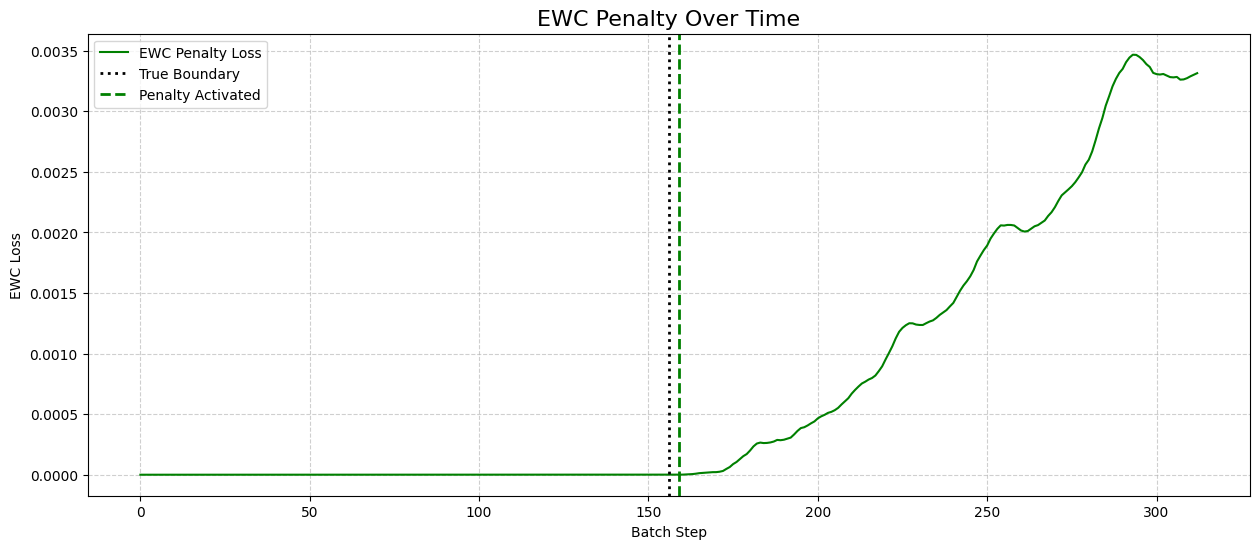

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

print("\n--- Plot 5: EWC Penalty Loss Over Time ---")

try:
    df = pd.read_csv('training_log.csv')
except FileNotFoundError:
    print("ERROR: 'training_log.csv' not found. Please run the main training cell first.")
    df = pd.DataFrame(columns=['step', 'ewc_loss'])
except Exception as e:
    print(f"An error occurred reading the log file: {e}")
    df = pd.DataFrame(columns=['step', 'ewc_loss'])

# --- Find boundary step info ---
try:
    true_boundary_step = (len(X_train_1) * EPOCHS_PER_TASK) // BATCH_SIZE
except NameError:
    true_boundary_step = 156 # Fallback

detected_step = df[df['ewc_loss'] > 0].first_valid_index()
if detected_step is None:
    detected_step = true_boundary_step # Fallback

# --- Plot the figure ---
plt.figure(figsize=(15, 6))

plt.plot(df['step'], df['ewc_loss'], label='EWC Penalty Loss', color='green')
plt.axvline(x=true_boundary_step, color='black', linestyle=':', linewidth=2, label='True Boundary')
plt.axvline(x=detected_step, color='green', linestyle='--', linewidth=2, label='Penalty Activated')

plt.title('EWC Penalty Over Time', fontsize=16)
plt.ylabel('EWC Loss')
plt.xlabel('Batch Step')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('abd_ewc_penalty_plot.png', dpi=150)
plt.savefig('abd_ewc_penalty_plot.pdf', bbox_inches='tight')
plt.show()


--- Plot 3: Forgetting Analysis (Task 1 Before vs. After) ---


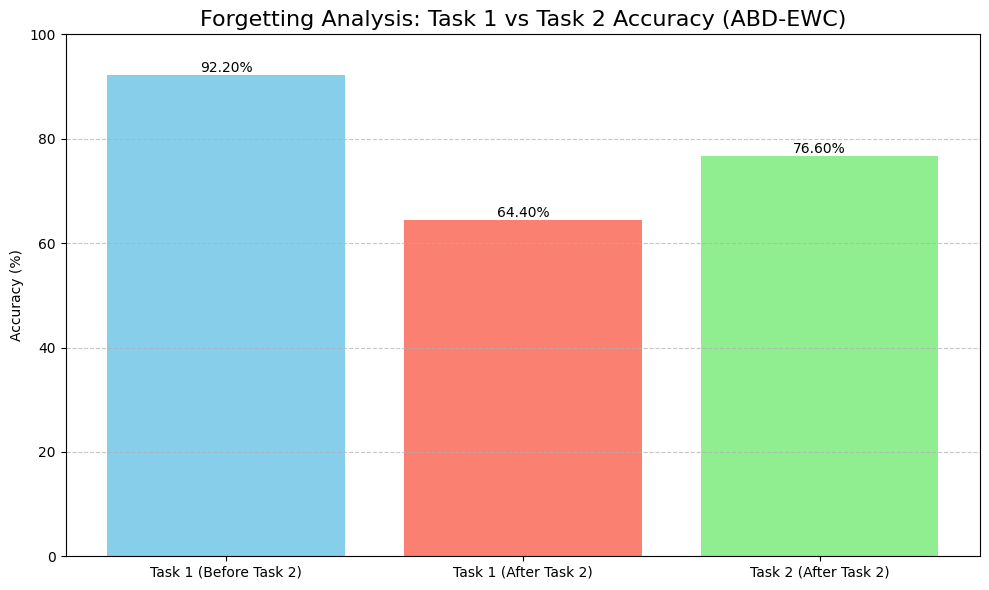

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

print("\n--- Plot 3: Forgetting Analysis (Task 1 Before vs. After) ---")

def plot_forgetting_bar_chart(log_file='training_log.csv'):
    """
    Plots a bar chart comparing Task 1 accuracy *before* Task 2
    was introduced, to the *final* accuracy of Task 1 and Task 2.
    """

    acc_t1_before = np.nan
    acc_t1_after = np.nan
    acc_t2_after = np.nan

    # --- 1. Get "Task 1 After" and "Task 2 After" accuracies ---
    try:
        acc_t1_after = results_A[1] * 100
        acc_t2_after = results_B[1] * 100
    except NameError:
        print("ERROR: 'results_A' and 'results_B' variables not found.")
        print("Please run your 'Final Evaluation' cell before running this plot cell.")
        return
    except Exception as e:
        print(f"An error occurred accessing results_A/results_B: {e}")
        return

    # --- 2. Get "Task 1 Before" accuracy from the log file ---
    try:
        df = pd.read_csv(log_file)
        true_boundary_step = (len(X_train_1) * EPOCHS_PER_TASK) // BATCH_SIZE

        # Find the last logged validation accuracy *before* the boundary
        df_t1_before = df[df['step'] < true_boundary_step]['val_a_acc']
        last_val_index = df_t1_before.last_valid_index()

        if last_val_index is not None:
            acc_t1_before = df.iloc[last_val_index]['val_a_acc'] * 100
        else:
            print("Warning: Could not find 'val_a_acc' before the boundary. 'Task 1 Before' will be 0.")
            acc_t1_before = 0.0

    except FileNotFoundError:
        print(f"ERROR: '{log_file}' not found. Cannot get 'Task 1 Before' accuracy.")
        return
    except Exception as e:
        print(f"An error occurred: {e}")
        return

    # --- 3. Plot the bar chart ---
    labels = ['Task 1 (Before Task 2)', 'Task 1 (After Task 2)', 'Task 2 (After Task 2)']
    accuracies = [acc_t1_before, acc_t1_after, acc_t2_after]
    colors = ['skyblue', 'salmon', 'lightgreen']

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(labels, accuracies, color=colors)

    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Forgetting Analysis: Task 1 vs Task 2 Accuracy (ABD-EWC)', fontsize=16)
    ax.set_ylim(0, 100)
    ax.grid(True, linestyle='--', axis='y', alpha=0.7)

    ax.bar_label(bars, fmt='%.2f%%')

    plt.tight_layout()
    plt.savefig('forgetting_analysis_bar_chart.png', dpi=150)
    plt.savefig('forgetting_analysis_bar_chart.pdf', bbox_inches='tight')
    plt.show()

# --- Run the function ---
plot_forgetting_bar_chart()


--- Plot 4: Automatic Boundary Detection (Entropy Spike) ---


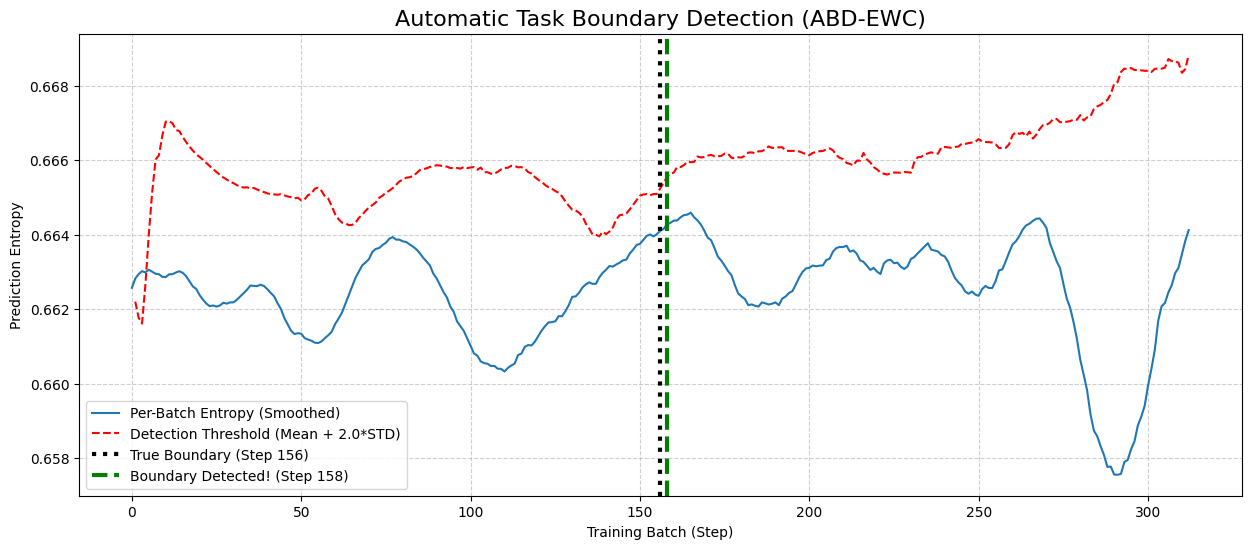

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

print("\n--- Plot 4: Automatic Boundary Detection (Entropy Spike) ---")

try:
    df = pd.read_csv('training_log.csv')
except FileNotFoundError:
    print("ERROR: 'training_log.csv' not found. Please run the main training cell first.")
    df = pd.DataFrame(columns=['step', 'batch_entropy'])
except Exception as e:
    print(f"An error occurred reading the log file: {e}")
    df = pd.DataFrame(columns=['step', 'batch_entropy'])

# --- Re-create parameters from your training loop for plotting ---
BETA_TRIGGER = 2.0
HISTORY_LENGTH = 50
BATCH_SIZE = 32

try:
    true_boundary_step = (len(X_train_1) * EPOCHS_PER_TASK) // BATCH_SIZE
except NameError:
    true_boundary_step = 156 # Fallback

# --- Calculate rolling stats for plotting ---
df['entropy_smooth'] = df['batch_entropy'].rolling(window=20, min_periods=1, center=True).mean()
df['rolling_mean'] = df['batch_entropy'].rolling(window=HISTORY_LENGTH, min_periods=1).mean()
df['rolling_std'] = df['batch_entropy'].rolling(window=HISTORY_LENGTH, min_periods=1).std()
df['threshold'] = df['rolling_mean'] + (BETA_TRIGGER * (df['rolling_std'] + 1e-9))

# --- Find the *actual* detected step ---
detected_df = df[ (df['batch_entropy'] > df['threshold']) & (df.index > HISTORY_LENGTH) & (df.index > true_boundary_step) ]
if not detected_df.empty:
    detected_step = detected_df.index[0]
else:
    detected_step = None
    print("NOTE: No boundary spike was detected after the true boundary.")

# --- Plot the figure ---
plt.figure(figsize=(15, 6))
plt.plot(df['entropy_smooth'], label='Per-Batch Entropy (Smoothed)')
plt.plot(df['threshold'], label=f'Detection Threshold (Mean + {BETA_TRIGGER}*STD)',
         color='red', linestyle='--')

plt.axvline(x=true_boundary_step, color='black', linestyle=':',
            linewidth=3, label=f'True Boundary (Step {true_boundary_step})')

if detected_step:
    plt.axvline(x=detected_step, color='green', linestyle='--',
                linewidth=3, label=f'Boundary Detected! (Step {detected_step})')

plt.title('Automatic Task Boundary Detection (ABD-EWC)', fontsize=16)
plt.xlabel('Training Batch (Step)')
plt.ylabel('Prediction Entropy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('entropy_spike_plot.png', dpi=150)
plt.savefig('entropy_spike_plot.pdf', bbox_inches='tight')
plt.show()


--- Plot 1: Training vs. Validation Loss ---


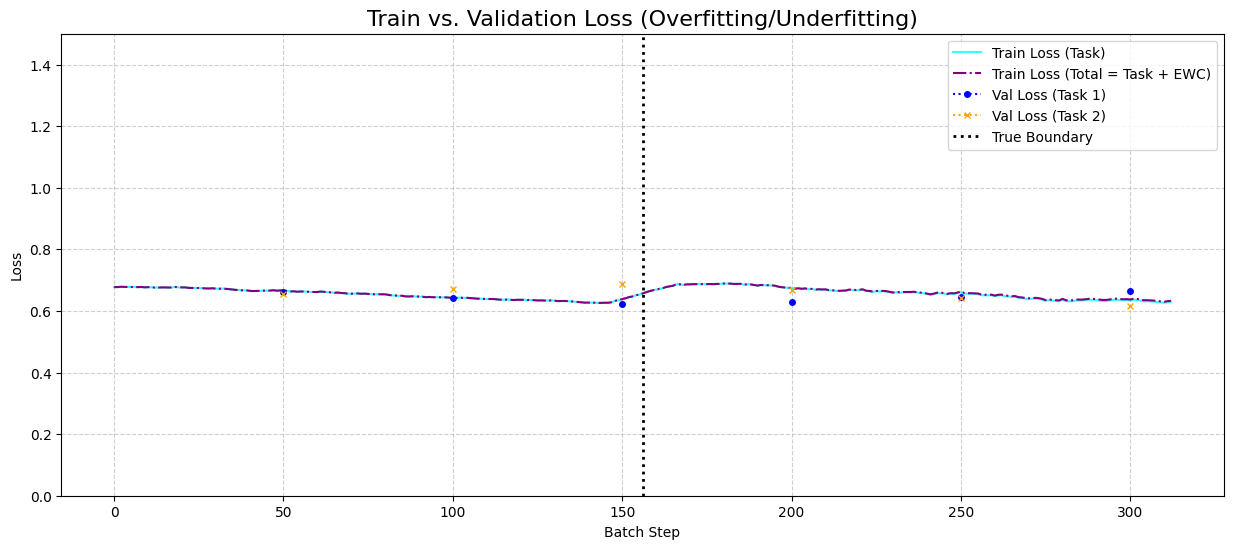

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

print("\n--- Plot 1: Training vs. Validation Loss ---")

try:
    df = pd.read_csv('training_log.csv')
except FileNotFoundError:
    print("ERROR: 'training_log.csv' not found. Please run the main training cell first.")
    # Create a dummy df to avoid crashing the rest of the code if file not found
    df = pd.DataFrame(columns=['step', 'task_loss', 'total_loss', 'val_a_loss', 'val_b_loss'])
except Exception as e:
    print(f"An error occurred reading the log file: {e}")
    df = pd.DataFrame(columns=['step', 'task_loss', 'total_loss', 'val_a_loss', 'val_b_loss'])

# --- Find boundary step info ---
try:
    true_boundary_step = (len(X_train_1) * EPOCHS_PER_TASK) // BATCH_SIZE
except NameError:
    true_boundary_step = 156 # Fallback

# --- Smooth the training loss for readability ---
df['task_loss_smooth'] = df['task_loss'].rolling(window=20, min_periods=1, center=True).mean()
df['total_loss_smooth'] = df['total_loss'].rolling(window=20, min_periods=1, center=True).mean()

# --- Plot the figure ---
plt.figure(figsize=(15, 6))

plt.plot(df['step'], df['task_loss_smooth'], label='Train Loss (Task)', alpha=0.8, color='cyan')
plt.plot(df['step'], df['total_loss_smooth'], label='Train Loss (Total = Task + EWC)',
         linestyle='-.', color='purple')

# Plot val loss (only where it's not NaN)
plt.plot(df['step'], df['val_a_loss'], label='Val Loss (Task 1)',
         linestyle=':', marker='o', markersize=4, color='blue')
plt.plot(df['step'], df['val_b_loss'], label='Val Loss (Task 2)',
         linestyle=':', marker='x', markersize=4, color='orange')

plt.axvline(x=true_boundary_step, color='black', linestyle=':', linewidth=2, label='True Boundary')
plt.title('Train vs. Validation Loss (Overfitting/Underfitting)', fontsize=16)
plt.ylabel('Loss')
plt.xlabel('Batch Step')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(bottom=0, top=1.5) # Adjust top as needed
plt.savefig('abd_loss_curves.png', dpi=150)
plt.savefig('abd_loss_curves.pdf', bbox_inches='tight')
plt.show()


--- Plot 2: Forgetting Analysis (Accuracy T1 vs. T2) ---


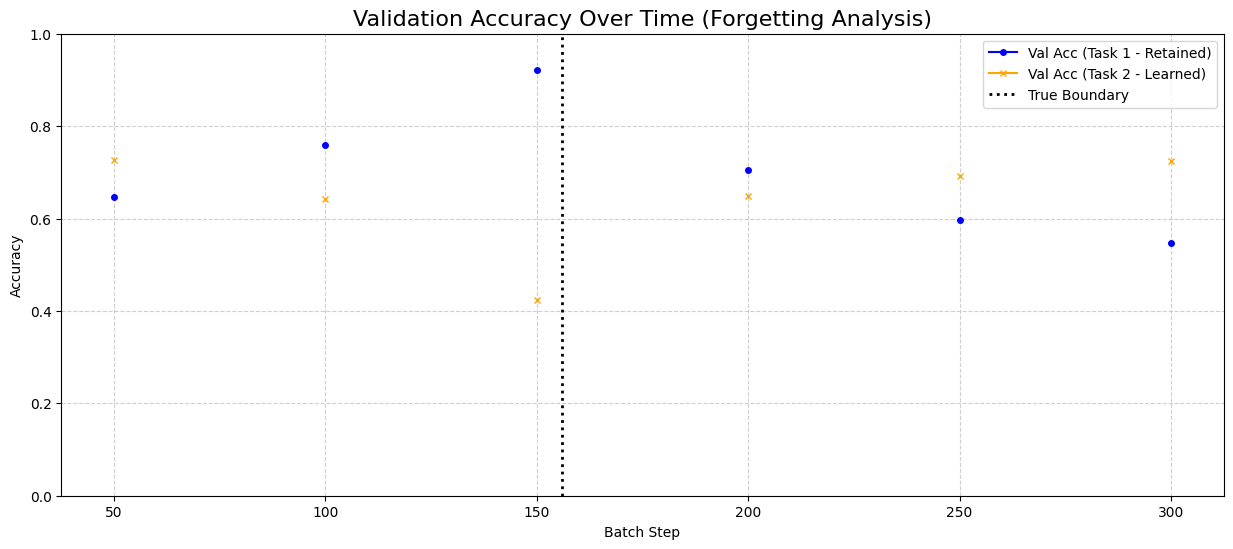

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

print("\n--- Plot 2: Forgetting Analysis (Accuracy T1 vs. T2) ---")

try:
    df = pd.read_csv('training_log.csv')
except FileNotFoundError:
    print("ERROR: 'training_log.csv' not found. Please run the main training cell first.")
    df = pd.DataFrame(columns=['step', 'val_a_acc', 'val_b_acc'])
except Exception as e:
    print(f"An error occurred reading the log file: {e}")
    df = pd.DataFrame(columns=['step', 'val_a_acc', 'val_b_acc'])

# --- Find boundary step info ---
try:
    true_boundary_step = (len(X_train_1) * EPOCHS_PER_TASK) // BATCH_SIZE
except NameError:
    true_boundary_step = 156 # Fallback

# --- Plot the figure ---
plt.figure(figsize=(15, 6))

plt.plot(df['step'], df['val_a_acc'], label='Val Acc (Task 1 - Retained)',
         linestyle='-', marker='o', markersize=4, color='blue')
plt.plot(df['step'], df['val_b_acc'], label='Val Acc (Task 2 - Learned)',
         linestyle='-', marker='x', markersize=4, color='orange')

plt.axvline(x=true_boundary_step, color='black', linestyle=':', linewidth=2, label='True Boundary')
plt.title('Validation Accuracy Over Time (Forgetting Analysis)', fontsize=16)
plt.ylabel('Accuracy')
plt.xlabel('Batch Step')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, 1) # Accuracy is 0-1
plt.savefig('abd_accuracy_curves.png', dpi=150)
plt.savefig('abd_accuracy_curves.pdf', bbox_inches='tight')
plt.show()